# 1- Import libraries

In [2]:
# ====== INSTALL REQUIRED PACKAGES ======
!pip install scikit-learn scikit-optimize wordcloud nltk

# ====== IMPORTS ======
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import html
import sklearn.exceptions

# NLP tools
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Wordcloud
from wordcloud import WordCloud

# Machine learning & optimization
from skopt import BayesSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression

# Warnings ko ignore karna
warnings.filterwarnings("ignore", category=sklearn.exceptions.UndefinedMetricWarning)

# Inline plots for Colab
%matplotlib inline


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.9 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


# 2- Load data and drop unused column

In [8]:
root = "/content/"

df_train = pd.read_csv(root + "train.csv", encoding='latin-1', usecols=range(3))
df_test = pd.read_csv(root + "test.csv", encoding='latin-1', usecols=range(2))
df_test.insert(loc=1, column="Sentiment", value=np.nan)

# append ki jagah concat
df = pd.concat([df_train, df_test], ignore_index=True, sort=False)

df = df.drop(['ItemID'], axis=1)


# 3- Remove duplicates if any and preview the data

In [9]:
print(len(df))
df = df.drop_duplicates()
df.head()

299987


,Sentiment,SentimentText
0,0.0,is so sad for my APL frie...
1,0.0,I missed the New Moon trail...
2,1.0,omg its already 7:30 :O
3,0.0,.. Omgaga. Im sooo im gunna CRy. I'...
4,0.0,i think mi bf is cheating on me!!! ...


# 4- Summarized information of the data

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299987 entries, 0 to 299986
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Sentiment      99989 non-null   float64
 1   SentimentText  299987 non-null  object 
dtypes: float64(1), object(1)
memory usage: 4.6+ MB


# 5- Check for unique values and normalize if necessary

In [11]:
df.nunique()

,0
Sentiment,2
SentimentText,299987


# 6- Statistical description of the data

In [12]:
df.describe()

,Sentiment
count,99989.000000
mean,0.564632
std,0.495808
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


# 7- Visualize the data

## Distribution of the class label with a bar-chart

Text(0, 0.5, 'Number of instances')

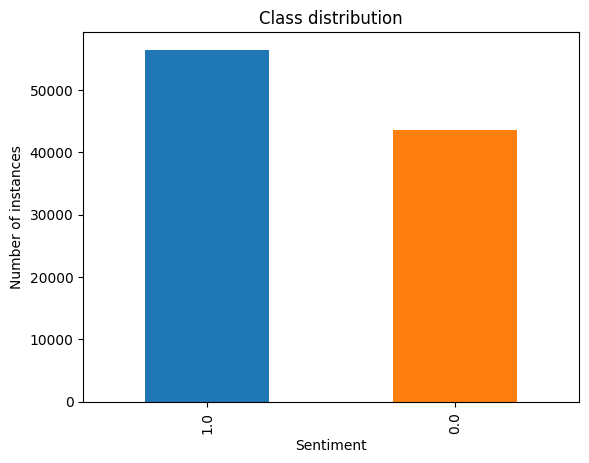

In [13]:
ax = df['Sentiment'].value_counts().plot.bar(title="Class distribution", color=['C0', 'C1'])
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of instances")

# 8- Feature engineering

## Check missing values in columns

In [14]:
df.isnull().sum()

,0
Sentiment,199998
SentimentText,0


## Clean the tweets

In [16]:
# Clean a tweet
def function_clean_tweet(text):
    # Escaping HTML characters
    text = html.unescape(text)
    # Removal of URLs
    text = re.sub(r"http\S+", "", text)
    # Removal of mentions
    text = re.sub(r"@[^\s]*", "", text)
    # Removal of hashtags
    text = re.sub(r"#[^\s]*", "", text)
    # Removal of numbers
    text = re.sub(r'[0-9]*[+-:]*[0-9]+', "", text)
    # Convert to lowercase
    text = text.lower()
    # Removal of repeating characters (more than two consecutive characters)
    text = re.sub(r'(.)\1+', r'\1\1', text)
    # Apostrophe lookup
    text = re.sub("'ll", " will", text)
    text = re.sub("'ve", " have", text)
    text = re.sub("n't", " not", text)
    text = re.sub("'d", " would", text)
    text = re.sub("'re", " are", text)
    text = re.sub("i'm", "i am", text)
    text = re.sub("it's", "it is", text)
    text = re.sub("she's", "she is", text)
    text = re.sub("he's", "he is", text)
    text = re.sub("here's", "here is", text)
    text = re.sub("that's", "that is", text)
    text = re.sub("there's", "there is", text)
    text = re.sub("what's", "what is", text)
    text = re.sub("who's", "who is", text)
    text = re.sub("'s", "", text)
    # Removal of punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Handling slang words
    text = re.sub(r"\btmrw\b", "tomorrow", text)
    text = re.sub(r"\bur\b", "your", text)
    text = re.sub(r"\burs\b", "yours", text)
    text = re.sub(r"\bppl\b", "people", text)
    text = re.sub(r"\byrs\b", "years", text)
    # Handling acronyms
    text = re.sub(r"\b(rt)\b", "retweet", text)
    text = re.sub(r"\b(btw)\b", "by the way", text)
    text = re.sub(r"\b(asap)\b", "as soon as possible", text)
    text = re.sub(r"\b(fyi)\b", "for your information", text)
    text = re.sub(r"\b(tbt)\b", "throwback thursday", text)
    text = re.sub(r"\b(tba)\b", "to be announced", text)
    text = re.sub(r"\b(tbh)\b", "to be honest", text)
    text = re.sub(r"\b(faq)\b", "frequently asked questions", text)
    text = re.sub(r"\b(icymi)\b", "in case you missed it", text)
    text = re.sub(r"\b(aka)\b", "also known as", text)
    text = re.sub(r"\b(ama)\b", "ask me anything", text)
    # Removal of stop words
    stop_words = stopwords.words("english")
    text = " ".join([word for word in text.split() if word not in stop_words])
    # Word stemming
    stemmer = PorterStemmer()
    text = " ".join([stemmer.stem(word) for word in text.split()])
    # Word lemmatization
    lemmatizer = WordNetLemmatizer()
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])


In [18]:
import os

# Folder create karna (agar pehle se nahi hai to)
os.makedirs(root + '/After preprocessing', exist_ok=True)

# Ab safe save hoga
df['SentimentText'] = df['SentimentText'].apply(lambda text: function_clean_tweet(text))
df.to_csv(root + '/After preprocessing/train_TFIDF.csv', encoding='latin-1', index=False)

print(df['SentimentText'])


0                                            sad apl friend
1                                     miss new moon trailer
2                                               omg alreadi
3         omgaga im soo im gunna cri dentist sinc supo g...
4                                     think mi bf cheat t_t
                                ...                        
299982    morn petal work brought bank first holland sta...
299983    hellolittl bird final start rick movi morn got...
299984           got u work go buy one u know ima get u one
299985                        certainli give good interview
299986           feedback browser compat stori v loud clear
Name: SentimentText, Length: 299987, dtype: object


## Plot a cloud of words for each sentiment class

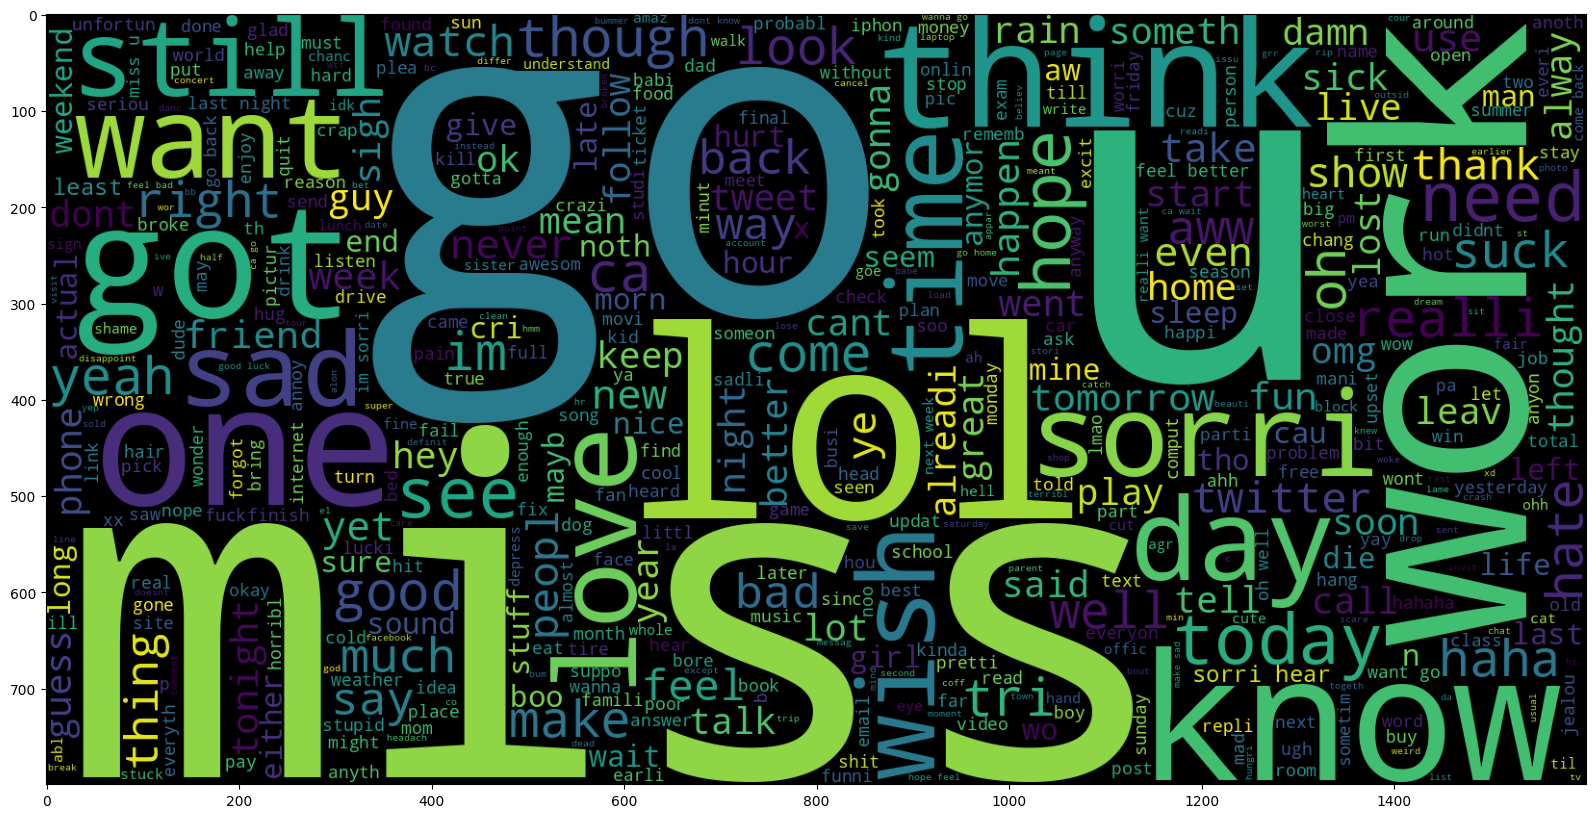

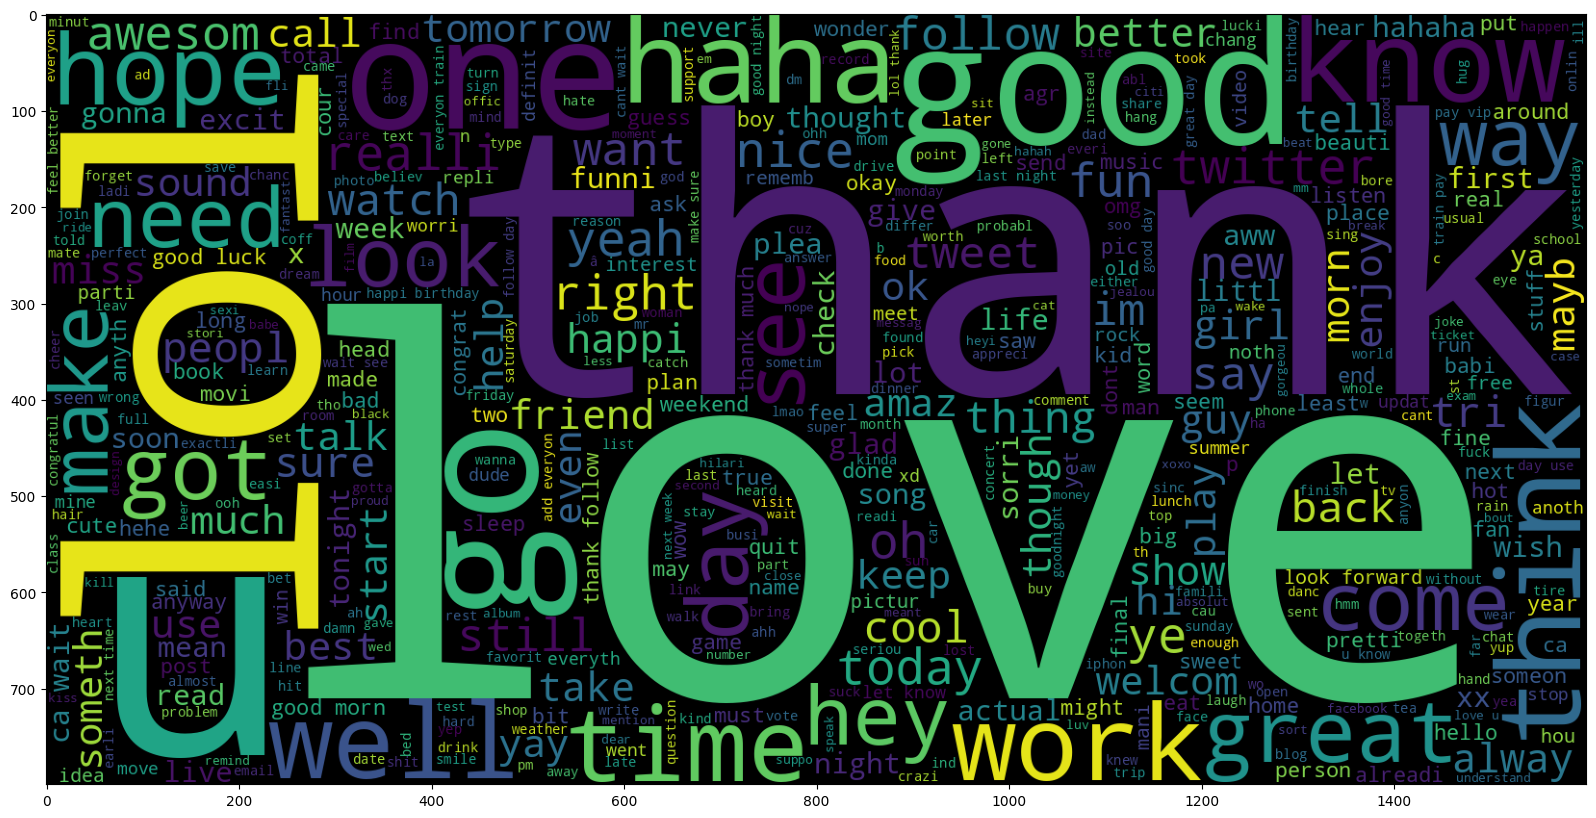

In [19]:
for sentiment_class in df['Sentiment'].dropna().unique():
    df_temp = df[df['Sentiment'] == sentiment_class]
    wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(' '.join(df_temp['SentimentText']))
    plt.figure(figsize=(20, 10))
    plt.imshow(wordcloud)

## Text vectorization: convert text into a numerical representation

In [20]:
vectorizer = TfidfVectorizer(
    min_df=2,            # ignore terms that have a document frequency strictly lower than 2
    ngram_range=(1, 1),  # (1, 2) for unigrams and bigrams
    max_features=10000)  # total number of words

# 9- Model construction: LogisticRegression

In [21]:
df.head()

,Sentiment,SentimentText
0,0.0,sad apl friend
1,0.0,miss new moon trailer
2,1.0,omg alreadi
3,0.0,omgaga im soo im gunna cri dentist sinc supo g...
4,0.0,think mi bf cheat t_t


## Train and test set

In [22]:
# Check that there are no duplicates before splitting
train, test = df[:len(df_train)], df[len(df_train):]
y_train = train['Sentiment']
X_train = train['SentimentText']
X_test = test['SentimentText']

## TF-IDF matrix (rows: tweets, columns: words)

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split
X_train, X_test, y_train, y_test = train_test_split(
    df['SentimentText'], df['Sentiment'], test_size=0.2, random_state=42
)

# Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)  # optional max_features
X_train = vectorizer.fit_transform(X_train)  # Fit on train
X_test = vectorizer.transform(X_test)        # Transform on test

print('No. of feature_words: ', len(vectorizer.get_feature_names_out()))
print(X_train.shape, X_test.shape)


No. of feature_words:  5000
(239989, 5000) (59998, 5000)


## Tune model hyperparameters with Bayesian search

In [33]:
from skopt import BayesSearchCV
from sklearn.linear_model import LogisticRegression

# define a valid search space
params = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],  # only these support l1+l2
    'max_iter': [1000]
}

# bayesian search
Bsearch = BayesSearchCV(
    LogisticRegression(),
    params,
    cv=5,
    scoring='f1_weighted',
    n_iter=10,
    random_state=5,
    verbose=True,
    error_score='raise'   # abhi error aayega toh proper traceback milega
)

# fit model
Bsearch.fit(X_train, y_train)

# best model
print("Best score:", Bsearch.best_score_)
print("Best params:", Bsearch.best_params_)
print("Best estimator:", Bsearch.best_estimator_)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best score: 0.7413115189417193
Best params: OrderedDict({'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'})
Best estimator: LogisticRegression(C=1, max_iter=1000, penalty='l1', solver='liblinear')


## Learning curve for various training set sizes

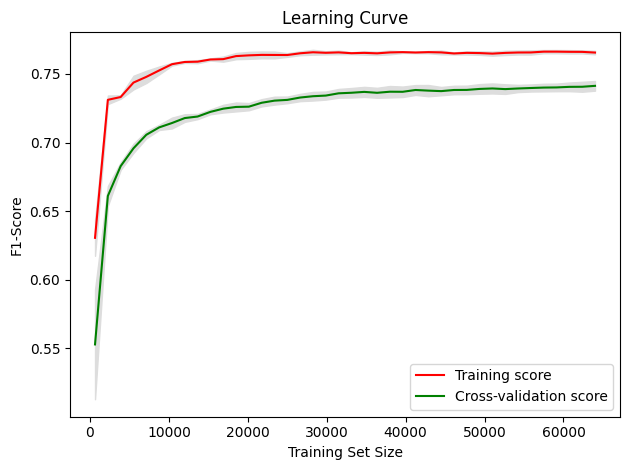

In [34]:
# Create CV training and test scores for various training set sizes (40 different sizes)
train_sizes, train_scores, test_scores = learning_curve(Bsearch.best_estimator_, X_train, y_train, train_sizes=np.linspace(0.01, 1.0, 40), cv=5, scoring='f1_weighted')

# Create means and standard deviations of training set scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# Create means and standard deviations of test set scores
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Draw lines
plt.plot(train_sizes, train_mean, color='r', label='Training score')
plt.plot(train_sizes, test_mean, color='g', label='Cross-validation score')

# Draw bands
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='#DDDDDD')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='#DDDDDD')

# Create plot
plt.title('Learning Curve')
plt.xlabel('Training Set Size'), plt.ylabel('F1-Score'), plt.legend(loc='best')
plt.tight_layout()
plt.show()

## Train the model on the train set

In [35]:
model = Bsearch.best_estimator_.fit(X_train, y_train)

## Evaluate the model on the test set

In [48]:
# Step 1: check columns
print("Test set columns:", df_test.columns)

# Step 2: use correct text column name 'SentimentText'
X_test = vectorizer.transform(df_test['SentimentText'].fillna(""))

# Step 3: predict
predictions = model.predict(X_test).astype(np.int64)

# Step 4: create submission
df_submission = pd.DataFrame({
    'ItemID': range(len(predictions)),  # Generate index if ItemID is not available
    'Sentiment': predictions
})

df_submission.to_csv(root + 'Sentiment_Analysis_predictions.csv', index=False)
print("✅ Submission ready:", df_submission.shape)

Test set columns: Index(['ItemID', 'Sentiment', 'SentimentText'], dtype='object')
✅ Submission ready: (199998, 2)


Training Metrics:
-----------------
Accuracy: 0.768

Classification Report:
              precision    recall  f1-score   support

         0.0       0.77      0.66      0.71     34782
         1.0       0.77      0.85      0.80     45209

    accuracy                           0.77     79991
   macro avg       0.77      0.76      0.76     79991
weighted avg       0.77      0.77      0.76     79991



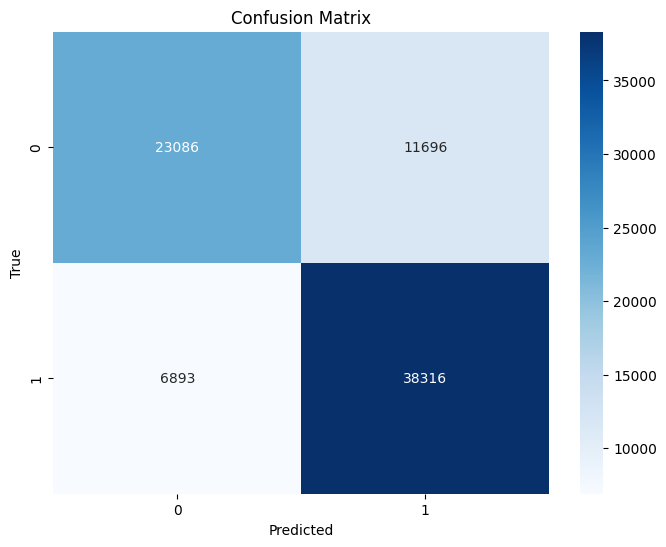

In [49]:
from sklearn.metrics import accuracy_score, classification_report

# Get predictions on training data for evaluation
train_predictions = model.predict(X_train)

# Calculate and display metrics
print("Training Metrics:")
print("-----------------")
print(f"Accuracy: {accuracy_score(y_train, train_predictions):.3f}\n")
print("Classification Report:")
print(classification_report(y_train, train_predictions))

# Visualize the confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_train, train_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Feature importance